In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()
X_train, X_test = X_train / 255.0, X_test / 255.0

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

model = models.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(100, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

model.save("cifar100_model.keras")



Epoch 1/20
1563/1563 [==============================] - 123s 78ms/step - loss: 4.3497 - accuracy: 0.0455 - val_loss: 3.9440 - val_accuracy: 0.0928
Epoch 2/20
1563/1563 [==============================] - 125s 80ms/step - loss: 4.0276 - accuracy: 0.0710 - val_loss: 3.6798 - val_accuracy: 0.1341
Epoch 3/20
1563/1563 [==============================] - 134s 86ms/step - loss: 3.8679 - accuracy: 0.0921 - val_loss: 3.6008 - val_accuracy: 0.1558
Epoch 4/20
1563/1563 [==============================] - 133s 85ms/step - loss: 3.7170 - accuracy: 0.1157 - val_loss: 3.3374 - val_accuracy: 0.2009
Epoch 5/20
1563/1563 [==============================] - 131s 84ms/step - loss: 3.5615 - accuracy: 0.1420 - val_loss: 3.1125 - val_accuracy: 0.2412
Epoch 6/20
1563/1563 [==============================] - 123s 79ms/step - loss: 3.4129 - accuracy: 0.1715 - val_loss: 3.0460 - val_accuracy: 0.2459
Epoch 7/20
1563/1563 [==============================] - 123s 79ms/step - loss: 3.2414 - accuracy: 0.2055 - val_loss: 2

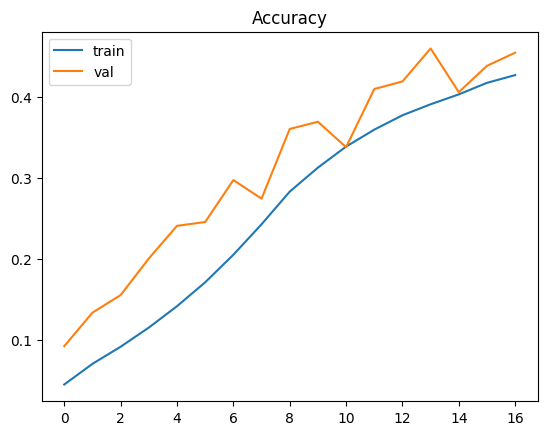

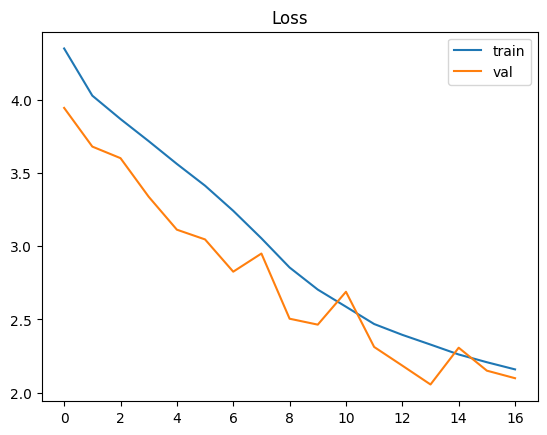

313/313 [==============================] - 5s 14ms/step - loss: 2.0556 - accuracy: 0.4600
Test Accuracy: 0.46000000834465027
313/313 [==============================] - 4s 13ms/step
Confusion Matrix:
 [[70  1  1 ...  0  0  0]
 [ 0 61  0 ...  0  0  1]
 [ 2  1 32 ...  1  5  0]
 ...
 [ 0  0  0 ... 38  0  0]
 [ 0  0  5 ...  0 24  0]
 [ 0  0  1 ...  0  0 36]]
              precision    recall  f1-score   support

           0       0.69      0.70      0.69       100
           1       0.64      0.61      0.62       100
           2       0.34      0.32      0.33       100
           3       0.20      0.15      0.17       100
           4       0.35      0.19      0.25       100
           5       0.51      0.40      0.45       100
           6       0.41      0.51      0.46       100
           7       0.60      0.37      0.46       100
           8       0.55      0.52      0.53       100
           9       0.57      0.51      0.54       100
          10       0.46      0.33      0.38      

In [11]:
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:\n", cm)

print(classification_report(y_test, y_pred_classes))